# 📡 Projeto de Classificação de Sonar: Rochas vs. Minas usando KNN

Este projeto aplica Machine Learning para identificar se um sinal de sonar reflete uma rocha submarina ou uma mina, com base em 60 frequências registradas. Usamos o algoritmo K-Nearest Neighbors (KNN) com validação cruzada e ajuste de hiperparâmetros.

## 🔗 Dataset original
Os dados foram extraídos do repositório da UCI Machine Learning: 📍 https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

# 🔍 Introdução ao problema
Sistemas de sonar emitem sinais sonoros e analisam os ecos que retornam. Com base na intensidade e frequência dessas ondas refletidas, é possível inferir se o objeto detectado é uma mina submarina (M) ou uma rocha (R).

O dataset contém:

- 208 amostras

- 60 colunas numéricas representando frequências de retorno

- 1 coluna final com o rótulo (M para mina, R para rocha)

## 🧪 Importação de bibliotecas e carregamento dos dados

In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [89]:
df = pd.read_csv("C:\\Users\\santo\\OneDrive\\Área de Trabalho\\UNZIP_FOR_NOTEBOOKS_FINAL (4)\\DATA\\sonar.all-data.csv")

In [91]:
df.head()

,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9,Freq_10,...,Freq_52,Freq_53,Freq_54,Freq_55,Freq_56,Freq_57,Freq_58,Freq_59,Freq_60,Label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 🧹 Separação de variáveis independentes e dependente

In [94]:
from sklearn.model_selection import train_test_split

# X contém as 60 frequências
X = df.drop('Label', axis=1)
# y contém o rótulo ('M' ou 'R')
y = df['Label']
# Divisão dos dados em treino (90%) e teste (10%)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,random_state=42)

## 🔧 Pré-processamento e criação do pipeline com KNN

In [97]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Padronização dos dados
scaler = StandardScaler()
# Classificador KNN
knn = KNeighborsClassifier()

# Pipeline de operações: escalonamento + KNN
operations = [('scaler',scaler), ('knn',knn)]
pipe = Pipeline(operations)


## 🔍 Ajuste de hiperparâmetros com GridSearchCV

In [100]:
from sklearn.model_selection import GridSearchCV

# Testaremos valores de k de 1 até 29
k_values = list(range(1,30))
param_grid = {'knn__n_neighbors': k_values}
# Validação cruzada com 5 folds
full_cv_classifier = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
full_cv_classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29]},
             scoring='accuracy')

## 🔎 Melhor valor de k encontrado

In [102]:
print(full_cv_classifier.best_estimator_.get_params())

{'memory': None, 'steps': [('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=1))], 'verbose': False, 'scaler': StandardScaler(), 'knn': KNeighborsClassifier(n_neighbors=1), 'scaler__copy': True, 'scaler__with_mean': True, 'scaler__with_std': True, 'knn__algorithm': 'auto', 'knn__leaf_size': 30, 'knn__metric': 'minkowski', 'knn__metric_params': None, 'knn__n_jobs': None, 'knn__n_neighbors': 1, 'knn__p': 2, 'knn__weights': 'uniform'}


## 📈 Visualização da acurácia para cada valor de k

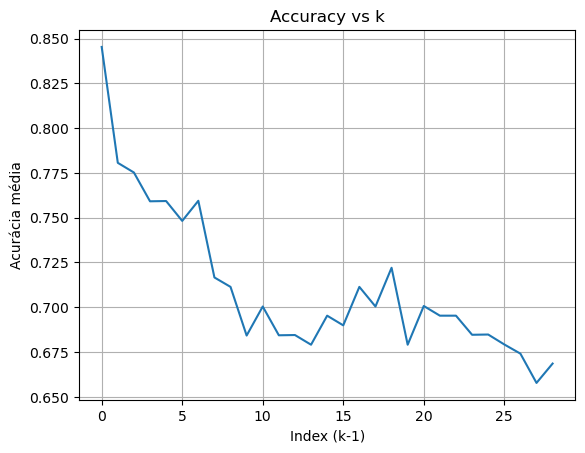

In [104]:
pd.DataFrame(full_cv_classifier.cv_results_)['mean_test_score'].plot(title='Accuracy vs k')
plt.xlabel('Index (k-1)')
plt.ylabel('Acurácia média')
plt.grid()
plt.show()

## 🧾 Avaliação do modelo no conjunto de teste

In [106]:
from sklearn.metrics import confusion_matrix, classification_report

# Previsão
pred = full_cv_classifier.predict(X_test)
# Matriz de confusão e métricas
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[12  1]
 [ 1  7]]
              precision    recall  f1-score   support

           M       0.92      0.92      0.92        13
           R       0.88      0.88      0.88         8

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



## 🔍 Previsão de uma nova amostra

In [117]:
frequencias = [0.0200, 0.0371, 0.0428, 0.0207, 0.1354, 0.2487, 0.3862, 0.4785, 0.5023, 0.6201,0.7110, 0.6932, 0.5814, 0.4675, 0.3598, 0.2784, 0.1967, 0.1420, 0.0856, 0.0712,0.0587, 0.0410, 0.0339, 0.0298, 0.0456, 0.0624, 0.0753, 0.0921, 0.1068, 0.1277,0.1495, 0.1748, 0.1983, 0.2136, 0.2297, 0.2480, 0.2641, 0.2876, 0.3059, 0.3287,0.3461, 0.3678, 0.3821, 0.3950, 0.4125, 0.4317, 0.4503, 0.4671, 0.4816, 0.4962,0.5124, 0.5293, 0.5471, 0.5639, 0.5810, 0.5963, 0.6127, 0.6315, 0.6492, 0.6634]
# # Pegando os nomes das colunas do X_train
colunas = X_train.columns
# Criando um DataFrame com as mesmas colunas
nova_amostra_df = pd.DataFrame([frequencias], columns=colunas)
# Fazendo a previsão
pred = full_cv_classifier.predict(nova_amostra_df)
print("Previsão:", pred[0])

Previsão: M


# 📌 Conclusão
Neste projeto:

- Usamos o algoritmo KNN com validação cruzada para encontrar o melhor número de vizinhos.

- O modelo foi treinado com dados reais de sonar e obteve bom desempenho.

- Uma nova amostra foi classificada como mina ou rocha com base em suas frequências.

 🚀 Este é um excelente exemplo prático de como dados físicos do mundo real podem ser transformados em decisões automatizadas com machine learning.